In [1]:
import requests
from pathlib import Path
import spacy
import re
import random
from collections import Counter
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from imblearn.over_sampling import SMOTE
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

import evaluate
metric = evaluate.load("accuracy")
import spacy
#!python -m spacy download pl_core_news_lg
nlp = spacy.load("pl_core_news_lg")

random.seed(40)

In [2]:
BOOK_API = 'https://wolnelektury.pl/api/books'
AUTHOR_API = 'https://wolnelektury.pl/api/authors'
OUTPUT_DIR = Path('data')
CHUNKS_DIR = Path('chunks')
PLOTS_DIR = Path('plots')

OUTPUT_DIR.mkdir(exist_ok=True)
CHUNKS_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

AUTHORS = ['boleslaw-prus', 'henryk-sienkiewicz', 
           'wladyslaw-stanislaw-reymont', 'stefan-zeromski', 'eliza-orzeszkowa']
N = 8

In [3]:
def get_txt(slug):
    url = f'{BOOK_API}/{slug}/'
    try:
        response = requests.get(url, timeout=15)
        response.raise_for_status()
        data = response.json()
        text_url = data['txt']
        response = requests.get(text_url, timeout=80)
        response.raise_for_status()
        return response.text
    except requests.RequestException as e:
        return None
        
def clean_txt(raw_txt):
    blocks = re.split(r'\n-{5}\n', raw_txt)
    raw_txt = '\n'.join(blocks[:-1])
    blocks = re.split(r'\n{3,}', raw_txt)
    cleaned = '\n\n\n'.join(blocks[2:]).strip()
    return cleaned

def author_N_texts(author_slug, n, min_chars=10000):
    try:
        url = f'{AUTHOR_API}/{author_slug}/books/'
        response = requests.get(url)
        response.raise_for_status()
        books = response.json()
        epics = [book for book in books if book['kind'] == 'Epika' and 
                 book['genre'] in ('Powieść', )]
        texts = []
        for book in epics:
            text = get_txt(book['slug'])
            if text and len(text) > min_chars:
                texts.append([book['slug'], text])
        sample = random.sample(texts, min(n, len(texts)))
        return sample
    except requests.RequestException as e:
        return None

<h1>Data extraction</h1>

In [4]:
for author in AUTHORS:
    records = author_N_texts(author, N)
    for rec in records:
        book_slug = rec[0]
        book_text = rec[1]
        txt_path = OUTPUT_DIR / f'{author}_{book_slug}.txt'
        Path(txt_path).write_text(book_text, encoding='utf-8')

In [5]:
for book in OUTPUT_DIR.iterdir():
    if book.is_file():
        raw_text = book.read_text(encoding='utf-8')
        cleaned_text = clean_txt(raw_text)
        book.write_text(cleaned_text, encoding='utf-8')

<h1>Analysis of given data</h1>

During the preliminary analysis of the texts, it was decided to filter out punctuation marks and stopwords, as their presence would significantly affect parameters such as token frequencies, part-of-speech frequencies, average word length, the number of unique words, and the number of hapax legomena. For the same reason, they will also be removed when analysing the frequency of individual parts of speech (POS).

Punctuation marks and stopwords will be taken into account only in the analysis of word and part-of-speech n-grams.

In [6]:
author_data = {author: {
    'n_sent': [],
    'sent_length': [],
    'word_length': [],
    'n_uniq': [],
    'hapax_legomenon': [],
    'dialogue_density': [],
    'POS_freq': [],
    'token_freq': [],
} for author in AUTHORS}

In [7]:
for record in OUTPUT_DIR.iterdir():
    if record.is_file():
        author, book = record.stem.split('_')
        text = record.read_text(encoding='utf-8')
        doc = nlp(text)
        
        word_tokens = [token.text.lower() for token in doc 
                       if not token.is_stop and not token.is_punct and not token.is_space]
        sent_tokens = [sent.text.lower() for sent in doc.sents]
        pos = [token.pos_ for token in doc
              if not token.is_stop and not token.is_punct and not token.is_space]
        n_uniq = len(set(word_tokens)) / len(word_tokens)
        
        token_freq = Counter(word_tokens)
        token_freq_norm = Counter({word: count / len(word_tokens) for word, count in token_freq.items()})
        n_sent = len(sent_tokens)
        sent_length = sum([len(sent.split()) for sent in sent_tokens]) / len(sent_tokens)
        word_length = sum([len(word) for word in word_tokens]) / len(word_tokens)
        pos_freq = Counter(pos)
        pos_freq_norm = Counter({pos: count / len(word_tokens) for pos, count in pos_freq.items()})
        hapax = sum(1 for word, count in token_freq.items() if count == 1) / len(word_tokens)
        dialogue_density = sum(1 for sent in sent_tokens if '—' in sent) / len(sent_tokens)
        
        author_data[author]['token_freq'].append(token_freq_norm)
        author_data[author]['n_sent'].append(n_sent)
        author_data[author]['sent_length'].append(sent_length)
        author_data[author]['word_length'].append(word_length)
        author_data[author]['POS_freq'].append(pos_freq_norm)
        author_data[author]['n_uniq'].append(n_uniq)
        author_data[author]['hapax_legomenon'].append(hapax)
        author_data[author]['dialogue_density'].append(dialogue_density)

<h2>Plots</h2>

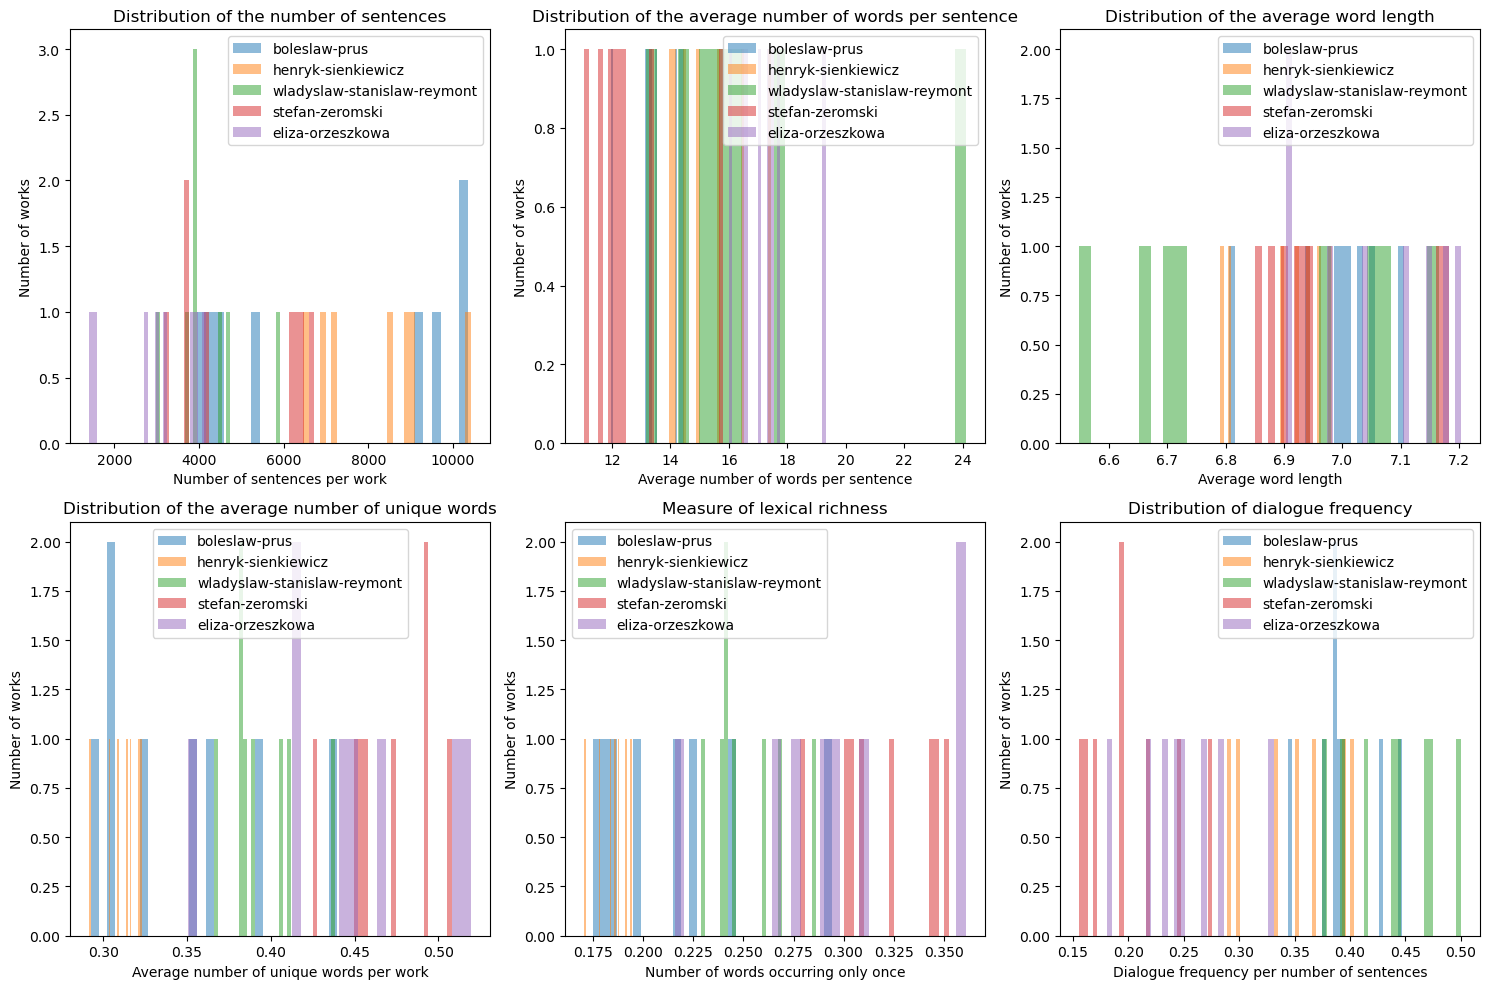

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

metrics = [
    ('n_sent', 'Distribution of the number of sentences', 'Number of sentences per work'),
    ('sent_length', 'Distribution of the average number of words per sentence', 'Average number of words per sentence'),
    ('word_length', 'Distribution of the average word length', 'Average word length'),
    ('n_uniq', 'Distribution of the average number of unique words', 'Average number of unique words per work'),
    ('hapax_legomenon', 'Measure of lexical richness', 'Number of words occurring only once'),
    ('dialogue_density', 'Distribution of dialogue frequency', 'Dialogue frequency per number of sentences')
]

for ax, (metric, title, xlabel) in zip(axes.flatten(), metrics):
    for author, data in author_data.items():
        ax.hist(data[metric], label=author, alpha=0.5, bins=30)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Number of works')
    ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / f'text_metrics.png', dpi=300)

The above charts show that the authors are mixed across all of the parameters; however, certain trends can be observed. For example, Reymont's works contain the most dialogue, while hapax legomena characterize the majority of Żeromski's works, etc.

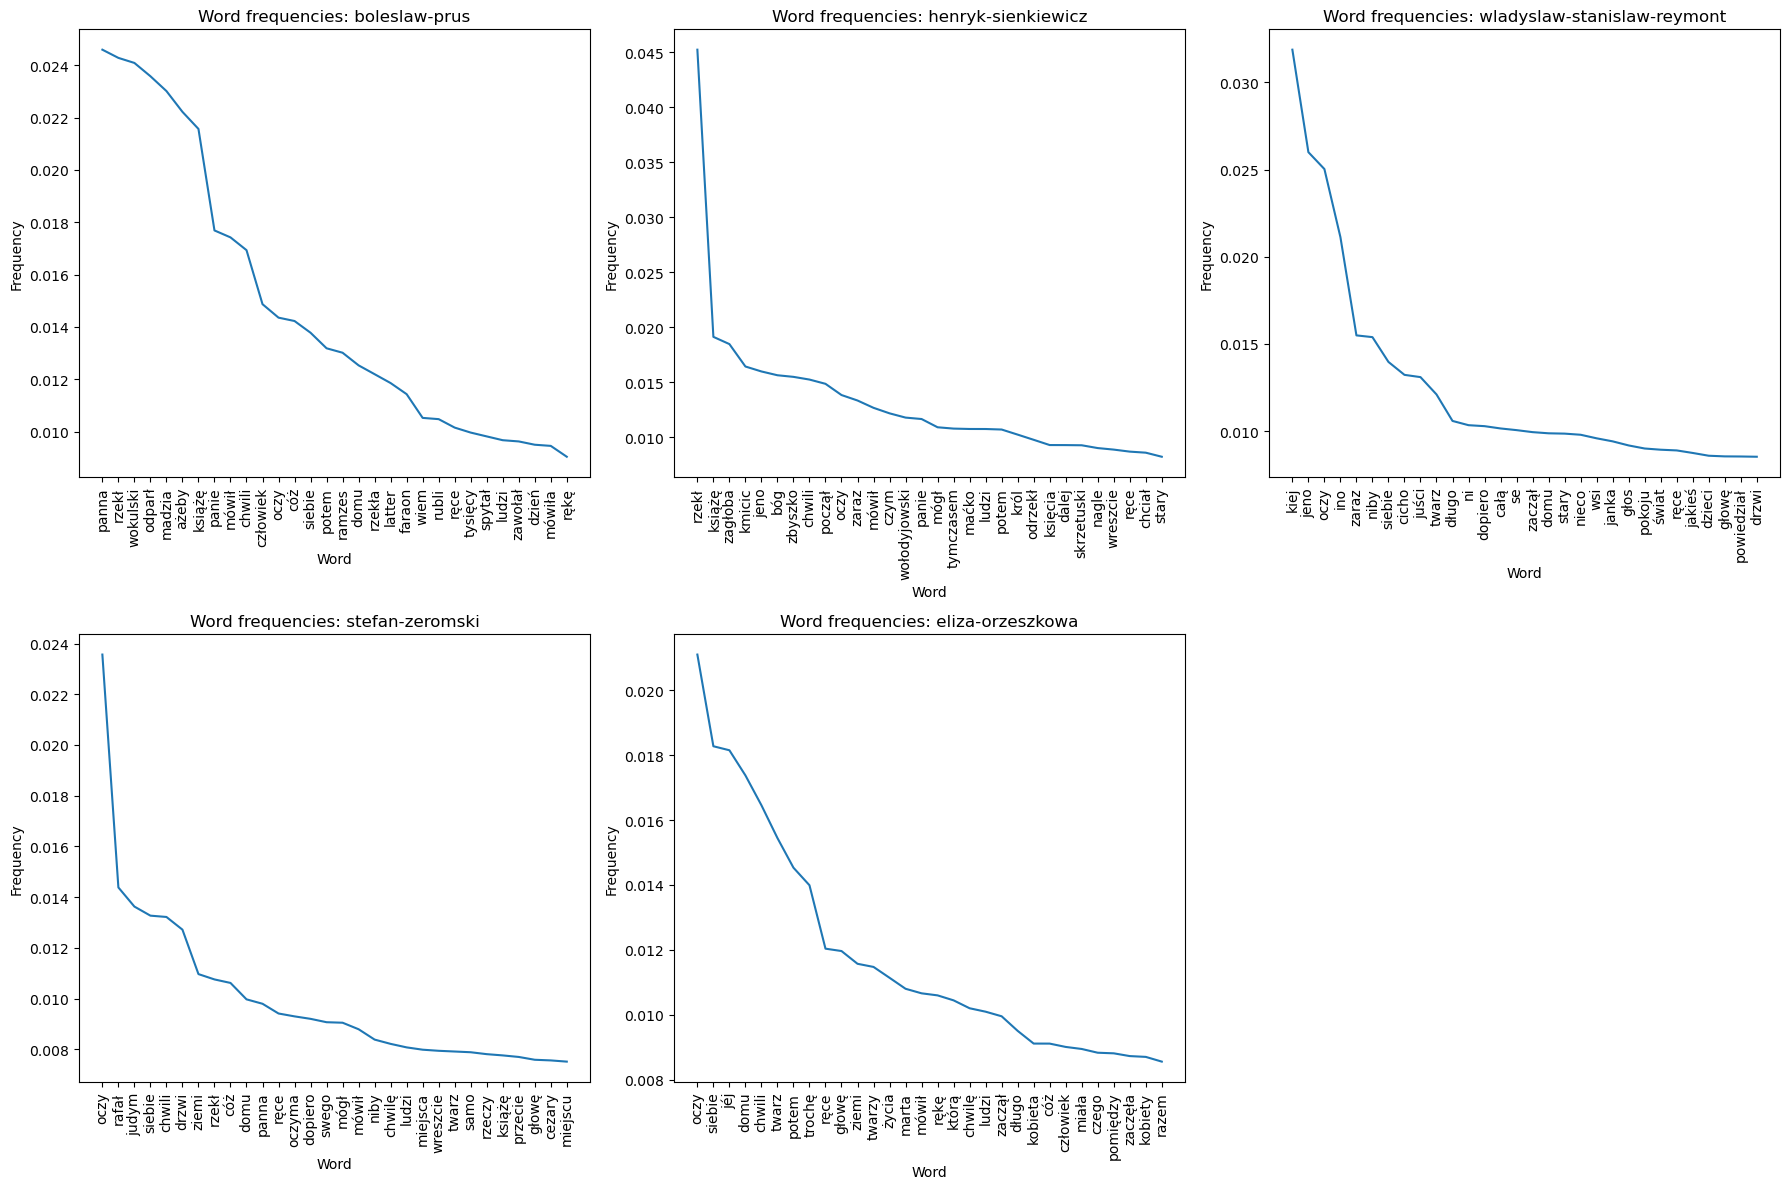

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, (author, data) in zip(axes.flatten(), author_data.items()):
    token_freq = sum(data['token_freq'], Counter())
    X = []
    Y = []
    for token, freq in token_freq.most_common()[:30]:
        X.append(token)
        Y.append(freq)
    ax.plot(X, Y)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title(f'Word frequencies: {author}')
    ax.set_xlabel('Word')
    ax.set_ylabel('Frequency')
axes[1][2].set_visible(False)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f'word_freqs.png', dpi=300)

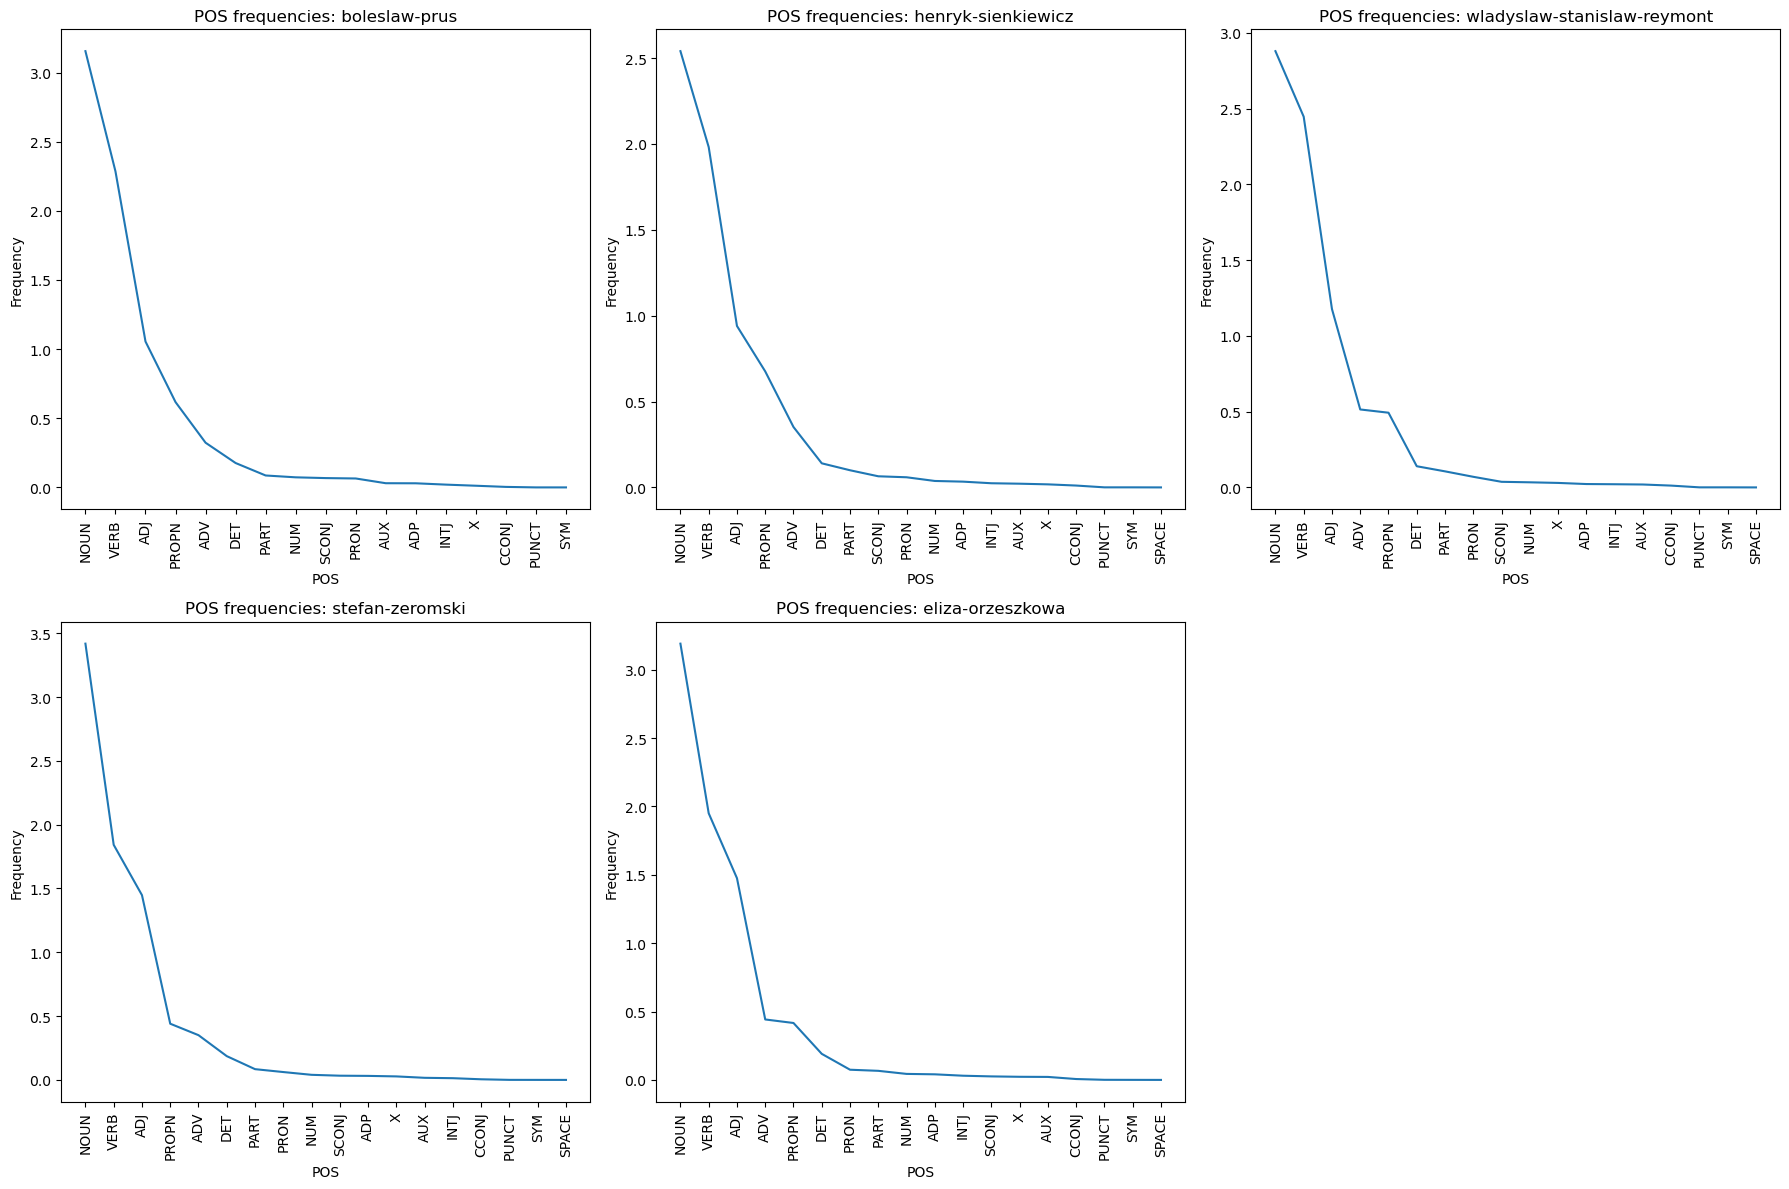

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, (author, data) in zip(axes.flatten(), author_data.items()):
    pos_freq = sum(data['POS_freq'], Counter())
    X = []
    Y = []
    for pos, freq in pos_freq.most_common()[:30]:
        X.append(pos)
        Y.append(freq)
    ax.plot(X, Y)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title(f'POS frequencies: {author}')
    ax.set_xlabel('POS')
    ax.set_ylabel('Frequency')
axes[1][2].set_visible(False)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f'pos_freqs.png', dpi=300)

<h2>Comparison of the Sets</h2>
Jaccard Similarity Measure for POS and Token (Word) Frequencies

In [11]:
def jaccard_idx(words_1, words_2):
    A = set(words_1)
    B = set(words_2)
    C = A.intersection(B)
    D = A.union(B)

    return float(len(C))/float(len(D))

In [12]:
author_token = defaultdict(list)
author_pos = defaultdict(list)

for author, data in author_data.items():
    token_freq = sum(data['token_freq'], Counter())
    pos_freq = sum(data['POS_freq'], Counter())
    
    for token, freq in token_freq.most_common()[:30]:
        author_token[author].append(token)
    for pos, freq in pos_freq.most_common()[:30]:
        author_pos[author].append(pos)

print('Similarities between the most frequently occurring tokens')
for author1 in author_token.keys():
    for author2 in author_token.keys():
        print(f'{author1} VS {author2}: {jaccard_idx(author_token[author1], author_token[author2])}')
print('---------------------------------------------------------')
print('Similarities between the most frequently occurring POS')
for author1 in author_pos.keys():
    for author2 in author_pos.keys():
        print(f'{author1} VS {author2}: {jaccard_idx(author_pos[author1], author_pos[author2])}')
print('---------------------------------------------------------')

Similarities between the most frequently occurring tokens
boleslaw-prus VS boleslaw-prus: 1.0
boleslaw-prus VS henryk-sienkiewicz: 0.17647058823529413
boleslaw-prus VS wladyslaw-stanislaw-reymont: 0.07142857142857142
boleslaw-prus VS stefan-zeromski: 0.22448979591836735
boleslaw-prus VS eliza-orzeszkowa: 0.22448979591836735
henryk-sienkiewicz VS boleslaw-prus: 0.17647058823529413
henryk-sienkiewicz VS henryk-sienkiewicz: 1.0
henryk-sienkiewicz VS wladyslaw-stanislaw-reymont: 0.09090909090909091
henryk-sienkiewicz VS stefan-zeromski: 0.17647058823529413
henryk-sienkiewicz VS eliza-orzeszkowa: 0.1111111111111111
wladyslaw-stanislaw-reymont VS boleslaw-prus: 0.07142857142857142
wladyslaw-stanislaw-reymont VS henryk-sienkiewicz: 0.09090909090909091
wladyslaw-stanislaw-reymont VS wladyslaw-stanislaw-reymont: 1.0
wladyslaw-stanislaw-reymont VS stefan-zeromski: 0.17647058823529413
wladyslaw-stanislaw-reymont VS eliza-orzeszkowa: 0.15384615384615385
stefan-zeromski VS boleslaw-prus: 0.22448979

When analysing the above values, it can be seen that comparing only the occurring POS tags will not provide us with a reliable classification of the authors' texts. The situation is different when considering the distribution of the filtered words, where the low Jaccard similarity values indicate a substantial difference between the sets.

<h1>Text Segmentation</h1>

In [13]:
SENTENCE_PER_CHUNK = 50

In [14]:
def get_chunks(full_txt, author):
    doc = nlp(full_txt)
    sentences = [sent.text.lower().strip() for sent in doc.sents]
    chunks = []
    for i in range(0, len(sentences), SENTENCE_PER_CHUNK):
        chunk = ' '.join(sentences[i:i+SENTENCE_PER_CHUNK])
        chunks.append([author, chunk])
    return chunks

In [15]:
chunks = []
for record in OUTPUT_DIR.iterdir():
    if record.is_file():
        author, book = record.stem.split('_')
        text = record.read_text(encoding='utf-8')
        chunks += get_chunks(text, author)

In [16]:
for data in chunks:
    if '&&' in data[1]:
        print(data[1])

In [17]:
with open(CHUNKS_DIR / 'chunks.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(f'{data[0]}&&{data[1].replace(chr(10), " ")}' for data in chunks))

<h2>Segmentation Analysis</h2>

In [18]:
input_data = []
with open(CHUNKS_DIR / 'chunks.txt', 'r', encoding='utf-8') as f:
    input_data = [line.strip().split('&&') for line in f]

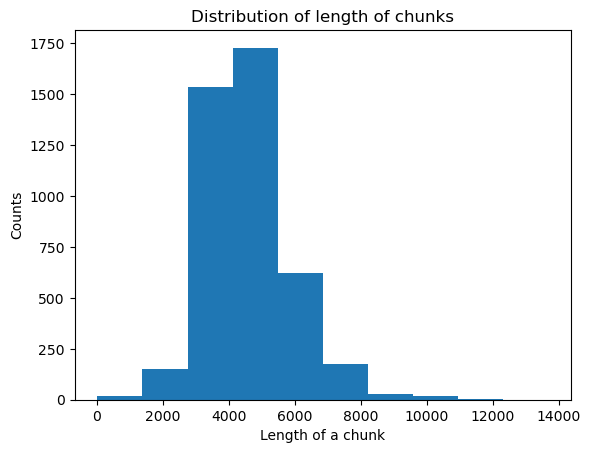

In [19]:
chunk_lengths = [len(chunk[1]) for chunk in input_data]
plt.hist(chunk_lengths)
plt.title('Distribution of length of chunks')
plt.xlabel('Length of a chunk')
plt.ylabel('Counts')
plt.savefig(PLOTS_DIR / f'chunk_length.png', dpi=300)

In [20]:
min(chunk_lengths)

16

In [21]:
chunk_authors = [chunk[0] for chunk in input_data]
Counter(chunk_authors)

Counter({'henryk-sienkiewicz': 1155,
         'boleslaw-prus': 1154,
         'stefan-zeromski': 812,
         'wladyslaw-stanislaw-reymont': 677,
         'eliza-orzeszkowa': 481})

In [22]:
random.shuffle(input_data)

<h1>Classification models</h1>

During this phase it is crucial to remove Proper Names, due to the fact that one of the parameters used in classification is TF-IDF for words used in given chunk.

In [23]:
EMBED_DIM = 128
N_CLASSES = 5

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

In [25]:
label_code = {}
for i, author in enumerate(AUTHORS):
    label_code[author] = i

In [26]:
X_raw = [data[1] for data in input_data]
y_raw = [label_code[data[0]] for data in input_data]

X, X_test, y, y_test = train_test_split(X_raw, y_raw, test_size = 0.2, random_state = 40)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.2, random_state = 40)

In [27]:
print(len(input_data))
print(len(X_train))
print(len(X_valid))
print(len(X_test))

4279
2738
685
856


In [28]:
print(Counter(y_train))
print(Counter(y_valid))
print(Counter(y_test))

Counter({1: 736, 0: 719, 3: 525, 2: 436, 4: 322})
Counter({0: 199, 1: 181, 3: 118, 2: 115, 4: 72})
Counter({1: 238, 0: 236, 3: 169, 2: 126, 4: 87})


Widać, że kategorie są niezbalansowane w zestawach danych. Z tego powodu użyty został SMOTE, aby dogenerować dane osobno dla zestawów danych przypadających na określony model.

It is evident that categories are inbalanced in every dataset. Therefore SMOTE was used for data generation in order to equalize group size.

In [29]:
def get_accuracy(model, data_loader):
    model.eval()
    correct, total = 0, 0  #How many is correct, Total amount 
    with torch.no_grad():
        for embeds, labels in data_loader: #iterating through data
            output = model(embeds)   #model output
            pred = output.max(1, keepdim=True)[1]  #which category
            correct += pred.eq(labels.view_as(pred)).sum().item()
            total += labels.shape[0]
    return correct / total

def get_topk_accuracy(model, data_loader, k=2): #k=2 because we have only 5 categories
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for embeds, labels in data_loader:
            output = model(embeds)
            topk_values, topk_indices = torch.topk(output, k, dim=1)
            matches = topk_indices.eq(labels.view(-1, 1)) #Vector -> matrix
            correct += matches.any(dim=1).sum().item()
            total += labels.shape[0]
    return correct / total

In [30]:
def train_network(model_name, model, train_loader, valid_loader, criterion, optimizer,
                  num_epochs=5):
    losses = []
    train_acc, train_acc_topk = [], []
    valid_acc, valid_acc_topk = [], []
    epochs = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0

        for embeds, labels in train_loader:
            optimizer.zero_grad()
            pred = model(embeds)
            loss = criterion(pred, labels)
            loss.backward()
            optimizer.step() #It works because optimizer have a reference to torch.nn.Parameter object inside model
            epoch_loss += loss.item()

        avg_epoch_loss = epoch_loss / len(train_loader)
        losses.append(avg_epoch_loss)

        if epoch % 10 == 0:
            epochs.append(epoch)
            train_acc.append(get_accuracy(model, train_loader))
            train_acc_topk.append(get_topk_accuracy(model, train_loader))
            valid_acc.append(get_accuracy(model, valid_loader))
            valid_acc_topk.append(get_topk_accuracy(model, valid_loader))
            print(f'Epoch {epoch+1} | Loss: {avg_epoch_loss:.4f} | Train Acc: {train_acc[-1]:.3f} | Valid Acc: {valid_acc[-1]:.3f}')

    # wykres strat
    plt.figure()
    plt.title("Loss per Epoch")
    plt.plot(losses, label="Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig(PLOTS_DIR / f'{model_name}_loss.png', dpi=300)
    plt.show()

    # wykres dokładności
    plt.figure()
    plt.title("Accuracy")
    plt.plot(epochs, train_acc, label="Train Accuracy")
    plt.plot(epochs, valid_acc, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.savefig(PLOTS_DIR / f'{model_name}_acc.png', dpi=300)
    plt.show()

    #wykres topk
    plt.figure()
    plt.title(f"Topk2 Accuracy")
    plt.plot(epochs, train_acc_topk, label="Train Topk2 Accuracy")
    plt.plot(epochs, valid_acc_topk, label="Validation Topk2 Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Topk2 accuracy")
    plt.legend()
    plt.savefig(PLOTS_DIR / f'{model_name}_acc_topk.png', dpi=300)
    plt.show()

<h2>Model no.1 (statistics)</h2>

In [31]:
def get_statistics(text):
    doc = nlp(text)
    word_tokens = [token.text.lower() for token in doc 
                       if not token.is_stop and not token.is_punct and not token.is_space
                       and token.pos_ != 'PROPN']
    sent_tokens = [sent.text.lower() for sent in doc.sents]
    token_freq = Counter(word_tokens)
    
    n_uniq = len(set(word_tokens)) / len(word_tokens)
    hapax = sum(1 for word, count in token_freq.items() if count == 1) / len(word_tokens)
    dialogue_density = sum(1 for sent in sent_tokens if '—' in sent) / len(sent_tokens)
    sent_length = sum([len(sent.split()) for sent in sent_tokens]) / len(sent_tokens)
    word_length = sum([len(word) for word in word_tokens]) / len(word_tokens)

    return [n_uniq, hapax, dialogue_density, sent_length, word_length]

In [32]:
stat_vectorizer = TfidfVectorizer(max_features = 30)
scaler = StandardScaler()

In [33]:
#Extracting statistics
X_train_stat_num = [get_statistics(text) for text in X_train] 
X_valid_stat_num = [get_statistics(text) for text in X_valid]

#Normalization
X_train_stat_num = scaler.fit_transform(X_train_stat_num)
X_valid_stat_num = scaler.transform(X_valid_stat_num)

#Computing TF-IDF for tokens
X_train_stat_tfidf = stat_vectorizer.fit_transform(X_train)
X_valid_stat_tfidf = stat_vectorizer.transform(X_valid)

#Merging data
X_train_stat = np.hstack([X_train_stat_num, X_train_stat_tfidf.toarray()])
X_valid_stat = np.hstack([X_valid_stat_num, X_valid_stat_tfidf.toarray()])

In [34]:
sm = SMOTE(random_state=42)
X_train_stat_res, y_train_stat_res = sm.fit_resample(X_train_stat, y_train)

In [35]:
X_train_stat = torch.tensor(X_train_stat_res, dtype=torch.float32)
y_train_stat = torch.tensor(y_train_stat_res, dtype=torch.long)

X_valid_stat = torch.tensor(X_valid_stat, dtype=torch.float32)
y_valid_stat = torch.tensor(y_valid, dtype=torch.long)

In [36]:
stat_train = []
stat_valid = []
for val, target in zip(X_train_stat, y_train_stat):
    stat_train.append((val, target))
for val, target in zip(X_valid_stat, y_valid_stat):
    stat_valid.append((val, target))

stat_train_loader = torch.utils.data.DataLoader(stat_train, batch_size=128, shuffle=True)
stat_valid_loader = torch.utils.data.DataLoader(stat_valid, batch_size=128, shuffle=True)

In [37]:
class StatModel(nn.Module):
    def __init__(self, input_dim, h1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Linear(h1, EMBED_DIM)
        )
        self.classifier = nn.Linear(EMBED_DIM, N_CLASSES)

    def forward(self, x, return_embedding=False):
        emb = self.encoder(x)
        if return_embedding:
            return emb
        return self.classifier(emb)

In [38]:
stat_input_dim = X_train_stat.shape[1]
stat_h1 = 256
stat_model = StatModel(stat_input_dim, stat_h1)
num_epochs = 150
lr = 0.01
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(stat_model.parameters(), lr=lr)

Epoch 1 | Loss: 1.0799 | Train Acc: 0.707 | Valid Acc: 0.667
Epoch 11 | Loss: 0.3727 | Train Acc: 0.871 | Valid Acc: 0.728
Epoch 21 | Loss: 0.2265 | Train Acc: 0.939 | Valid Acc: 0.759
Epoch 31 | Loss: 0.1545 | Train Acc: 0.933 | Valid Acc: 0.747
Epoch 41 | Loss: 0.0415 | Train Acc: 0.988 | Valid Acc: 0.766
Epoch 51 | Loss: 0.0829 | Train Acc: 0.970 | Valid Acc: 0.745
Epoch 61 | Loss: 0.0415 | Train Acc: 0.977 | Valid Acc: 0.765
Epoch 71 | Loss: 0.0807 | Train Acc: 0.985 | Valid Acc: 0.764
Epoch 81 | Loss: 0.0434 | Train Acc: 0.992 | Valid Acc: 0.780
Epoch 91 | Loss: 0.0009 | Train Acc: 1.000 | Valid Acc: 0.777
Epoch 101 | Loss: 0.0004 | Train Acc: 1.000 | Valid Acc: 0.775
Epoch 111 | Loss: 0.0003 | Train Acc: 1.000 | Valid Acc: 0.777
Epoch 121 | Loss: 0.0002 | Train Acc: 1.000 | Valid Acc: 0.778
Epoch 131 | Loss: 0.0001 | Train Acc: 1.000 | Valid Acc: 0.777
Epoch 141 | Loss: 0.0001 | Train Acc: 1.000 | Valid Acc: 0.777


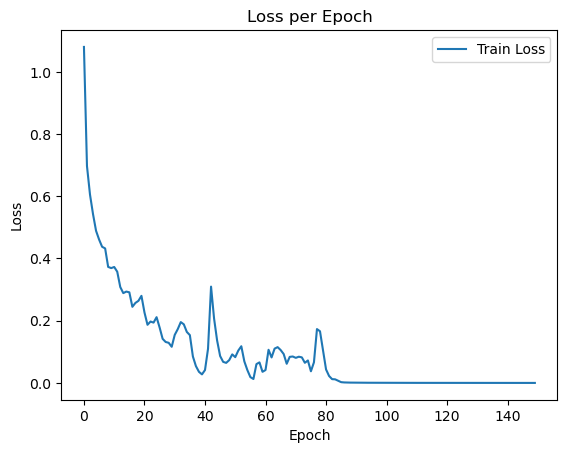

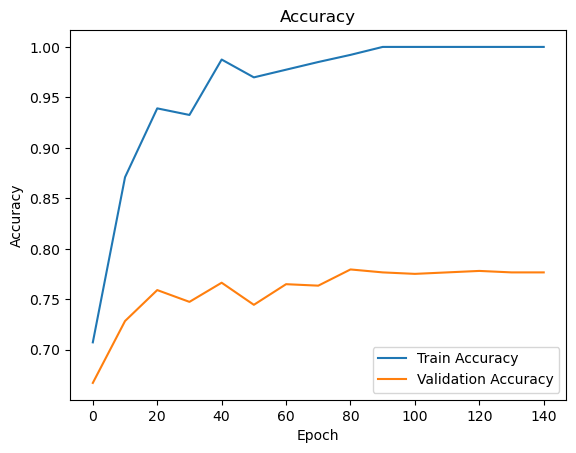

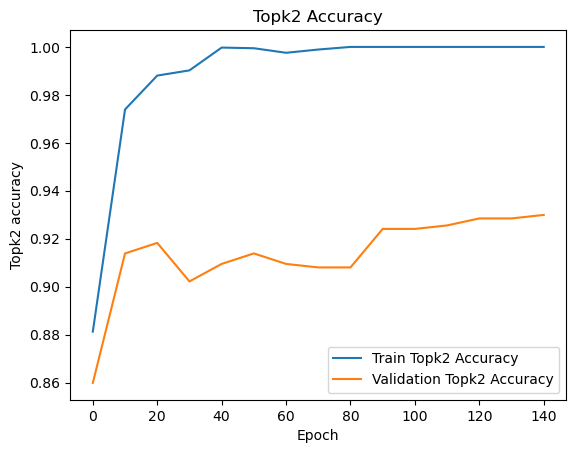

In [39]:
train_network('stat_model', stat_model, stat_train_loader, stat_valid_loader, criterion, optimizer,
              num_epochs)

Accuracy plots are showing minor problem with overfitting. In order to improve model accuracies on validation data:

1. Add Dropout(0.2)
2. Add weight_decay=1e-4
3. Reduce size of h1 layer
4. Reduce size of output layer (EMBED_DIM)

Major oscylation of cost function was also observed, therefore it was decided to decrease learning rate from 0.01 to 0.001.

In [40]:
class StatModel_v2(nn.Module):
    def __init__(self, input_dim, h1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(h1, EMBED_DIM)
        )
        self.classifier = nn.Linear(EMBED_DIM, N_CLASSES)

    def forward(self, x, return_embedding=False):
        emb = self.encoder(x)
        if return_embedding:
            return emb
        return self.classifier(emb)

In [41]:
EMBED_DIM = 64
stat_h1 = 128
stat_model = StatModel_v2(stat_input_dim, stat_h1)
num_epochs = 150
lr = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(stat_model.parameters(), lr=lr, weight_decay=1e-4)

Epoch 1 | Loss: 1.4578 | Train Acc: 0.499 | Valid Acc: 0.450
Epoch 11 | Loss: 0.7084 | Train Acc: 0.768 | Valid Acc: 0.727
Epoch 21 | Loss: 0.5573 | Train Acc: 0.822 | Valid Acc: 0.761
Epoch 31 | Loss: 0.4873 | Train Acc: 0.848 | Valid Acc: 0.772
Epoch 41 | Loss: 0.4469 | Train Acc: 0.864 | Valid Acc: 0.788
Epoch 51 | Loss: 0.4170 | Train Acc: 0.881 | Valid Acc: 0.794
Epoch 61 | Loss: 0.3919 | Train Acc: 0.893 | Valid Acc: 0.793
Epoch 71 | Loss: 0.3626 | Train Acc: 0.906 | Valid Acc: 0.803
Epoch 81 | Loss: 0.3447 | Train Acc: 0.909 | Valid Acc: 0.791
Epoch 91 | Loss: 0.3197 | Train Acc: 0.923 | Valid Acc: 0.799
Epoch 101 | Loss: 0.3055 | Train Acc: 0.928 | Valid Acc: 0.800
Epoch 111 | Loss: 0.2806 | Train Acc: 0.929 | Valid Acc: 0.793
Epoch 121 | Loss: 0.2706 | Train Acc: 0.941 | Valid Acc: 0.796
Epoch 131 | Loss: 0.2470 | Train Acc: 0.945 | Valid Acc: 0.804
Epoch 141 | Loss: 0.2435 | Train Acc: 0.952 | Valid Acc: 0.801


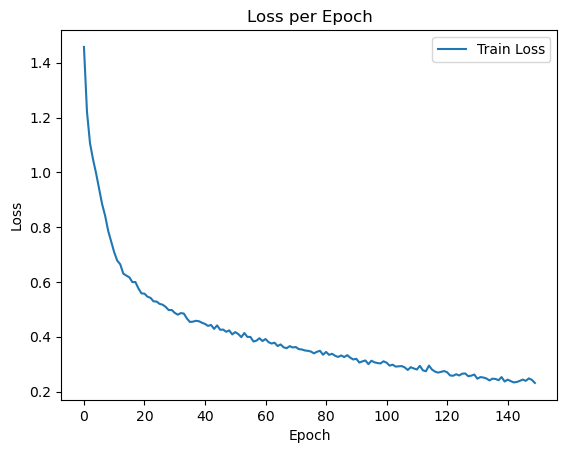

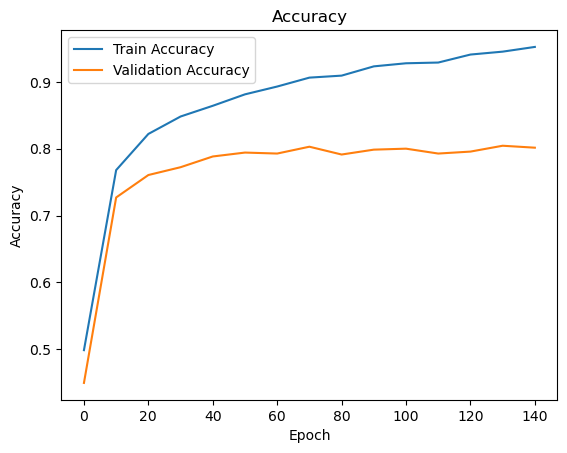

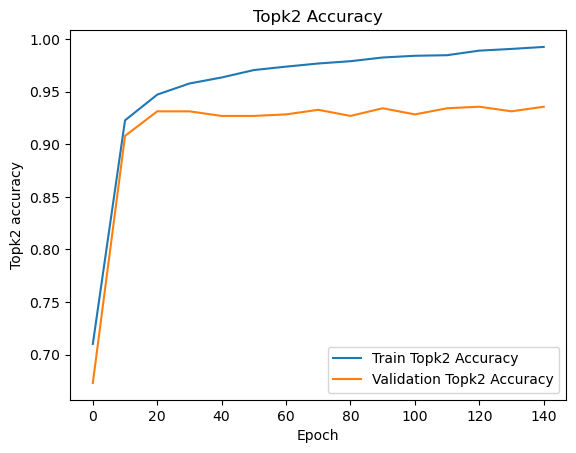

In [42]:
train_network('stat_model_v2', stat_model, stat_train_loader, stat_valid_loader, criterion, optimizer,
              num_epochs)

<h2>Model no.2 (N-grams)</h2>

In [43]:
sent_length = []
for record in OUTPUT_DIR.iterdir():
    if record.is_file():
        author, book = record.stem.split('_')
        text = record.read_text(encoding='utf-8')
        doc = nlp(text)
        sent_tokens = [sent.text.lower() for sent in doc.sents]
        sent_length.append(sum([len(sent.split()) for sent in sent_tokens]) / len(sent_tokens))
print(min(sent_length))

11.052946738102742


Since the shortest average sentence length in the text is equal 11 words, the range of (2,3) was selected as for the n-gram lengths. Additionally in this phase we will address existence of Proper Names, which can significantly influence the classification of given texts. In order to avoid an overly obvious division it was decided to replace Proper Names with ent_type_ tokens.

In [44]:
def mask_entity(text):
    doc = nlp(text)
    tokens = []
    for token in doc:
        if token.ent_type_:
            tokens.append(token.ent_type_)
        else:
            tokens.append(token.text.lower())
    return " ".join(tokens)

In [45]:
X_train_mask = [mask_entity(text) for text in X_train]
X_valid_mask = [mask_entity(text) for text in X_valid]

In [46]:
vectorizer = TfidfVectorizer(ngram_range=(2,3))
vectorizer.fit(X_train_mask)
print(len(vectorizer.vocabulary_))

2731808


In [47]:
ngram_vectorizer = TfidfVectorizer(ngram_range=(2,3), max_features=500)

In [48]:
#Computing TF-IDF for n-grams
X_train_ngram_tfidf = ngram_vectorizer.fit_transform(X_train_mask)
X_valid_ngram_tfidf = ngram_vectorizer.transform(X_valid_mask)

In [49]:
#Balancing categories
sm = SMOTE(random_state=42)
X_train_ngram_res, y_train_ngram_res = sm.fit_resample(X_train_ngram_tfidf.toarray(), y_train)

In [50]:
X_train_ngram = torch.tensor(X_train_ngram_res, dtype=torch.float32)
y_train_ngram = torch.tensor(y_train_ngram_res, dtype=torch.long)
X_valid_ngram = torch.tensor(X_valid_ngram_tfidf.toarray(), dtype=torch.float32)
y_valid_ngram = torch.tensor(y_valid, dtype=torch.long)

In [51]:
ngram_train = []
ngram_valid = []
for val, target in zip(X_train_ngram, y_train_ngram):
    ngram_train.append((val, target))
for val, target in zip(X_valid_ngram, y_valid_ngram):
    ngram_valid.append((val, target))

ngram_train_loader = torch.utils.data.DataLoader(ngram_train, batch_size=128, shuffle=True)
ngram_valid_loader = torch.utils.data.DataLoader(ngram_valid, batch_size=128, shuffle=True)

In [52]:
class NGramModel(nn.Module):
    def __init__(self, input_dim, h1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(h1, EMBED_DIM)
        )
        self.classifier = nn.Linear(EMBED_DIM, N_CLASSES)

    def forward(self, x, return_embedding=False):
        emb = self.encoder(x)
        if return_embedding:
            return emb
        return self.classifier(emb)

In [53]:
ngram_input_dim = X_train_ngram.shape[1]
ngram_h1 = 128
ngram_model = NGramModel(ngram_input_dim, ngram_h1)
num_epochs = 150
lr = 0.01
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(ngram_model.parameters(), lr=lr)

Epoch 1 | Loss: 0.7739 | Train Acc: 0.953 | Valid Acc: 0.915
Epoch 11 | Loss: 0.0096 | Train Acc: 1.000 | Valid Acc: 0.899
Epoch 21 | Loss: 0.0090 | Train Acc: 1.000 | Valid Acc: 0.867
Epoch 31 | Loss: 0.0143 | Train Acc: 1.000 | Valid Acc: 0.874
Epoch 41 | Loss: 0.0124 | Train Acc: 1.000 | Valid Acc: 0.886
Epoch 51 | Loss: 0.0104 | Train Acc: 0.999 | Valid Acc: 0.866
Epoch 61 | Loss: 0.0095 | Train Acc: 1.000 | Valid Acc: 0.879
Epoch 71 | Loss: 0.0176 | Train Acc: 1.000 | Valid Acc: 0.877
Epoch 81 | Loss: 0.0086 | Train Acc: 1.000 | Valid Acc: 0.860
Epoch 91 | Loss: 0.0106 | Train Acc: 1.000 | Valid Acc: 0.864
Epoch 101 | Loss: 0.0018 | Train Acc: 1.000 | Valid Acc: 0.858
Epoch 111 | Loss: 0.0127 | Train Acc: 1.000 | Valid Acc: 0.876
Epoch 121 | Loss: 0.0135 | Train Acc: 1.000 | Valid Acc: 0.869
Epoch 131 | Loss: 0.0110 | Train Acc: 1.000 | Valid Acc: 0.879
Epoch 141 | Loss: 0.0298 | Train Acc: 1.000 | Valid Acc: 0.877


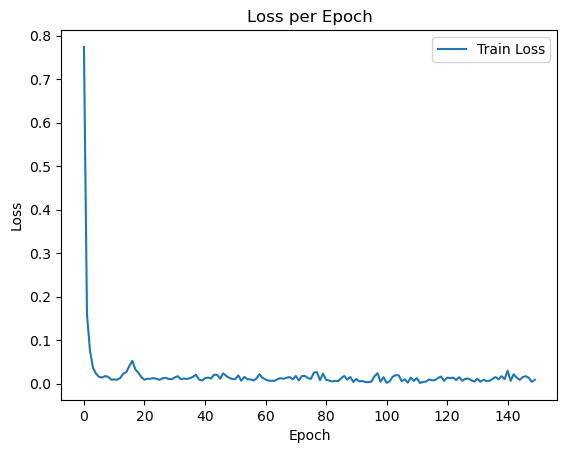

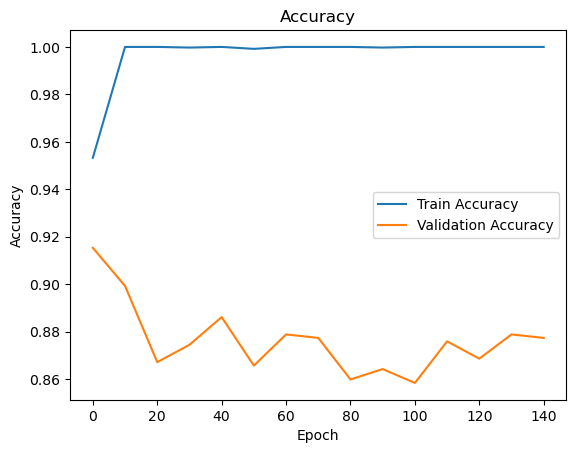

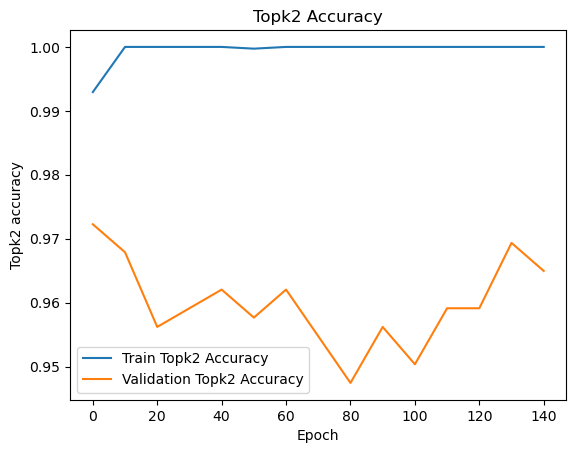

In [54]:
train_network('ngram_model', ngram_model, ngram_train_loader, ngram_valid_loader, criterion, optimizer,
              num_epochs)

As there is another problem with overfitting, appropriate modifications were applied:

1. Learning rate: 0.01 -> 0.0001
2. Number of epochs: 150 -> 200
3. weight_decay = 1e-3

In [55]:
ngram_h1 = 128
ngram_model = NGramModel(ngram_input_dim, ngram_h1)
num_epochs = 200
lr = 0.0001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(ngram_model.parameters(), lr=lr, weight_decay=1e-3)

Epoch 1 | Loss: 1.6115 | Train Acc: 0.300 | Valid Acc: 0.388
Epoch 11 | Loss: 1.3398 | Train Acc: 0.776 | Valid Acc: 0.780
Epoch 21 | Loss: 0.6481 | Train Acc: 0.911 | Valid Acc: 0.876
Epoch 31 | Loss: 0.3530 | Train Acc: 0.939 | Valid Acc: 0.901
Epoch 41 | Loss: 0.2383 | Train Acc: 0.957 | Valid Acc: 0.908
Epoch 51 | Loss: 0.1866 | Train Acc: 0.970 | Valid Acc: 0.911
Epoch 61 | Loss: 0.1507 | Train Acc: 0.979 | Valid Acc: 0.915
Epoch 71 | Loss: 0.1276 | Train Acc: 0.985 | Valid Acc: 0.918
Epoch 81 | Loss: 0.1072 | Train Acc: 0.988 | Valid Acc: 0.918
Epoch 91 | Loss: 0.0938 | Train Acc: 0.991 | Valid Acc: 0.918
Epoch 101 | Loss: 0.0797 | Train Acc: 0.993 | Valid Acc: 0.911
Epoch 111 | Loss: 0.0721 | Train Acc: 0.996 | Valid Acc: 0.908
Epoch 121 | Loss: 0.0670 | Train Acc: 0.997 | Valid Acc: 0.905
Epoch 131 | Loss: 0.0626 | Train Acc: 0.998 | Valid Acc: 0.905
Epoch 141 | Loss: 0.0567 | Train Acc: 0.998 | Valid Acc: 0.902
Epoch 151 | Loss: 0.0519 | Train Acc: 0.999 | Valid Acc: 0.907
Epo

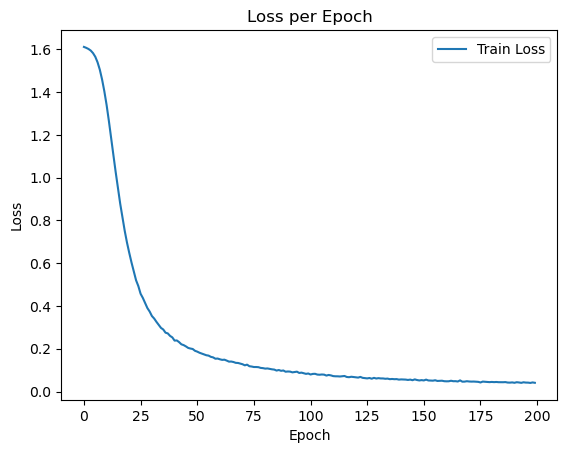

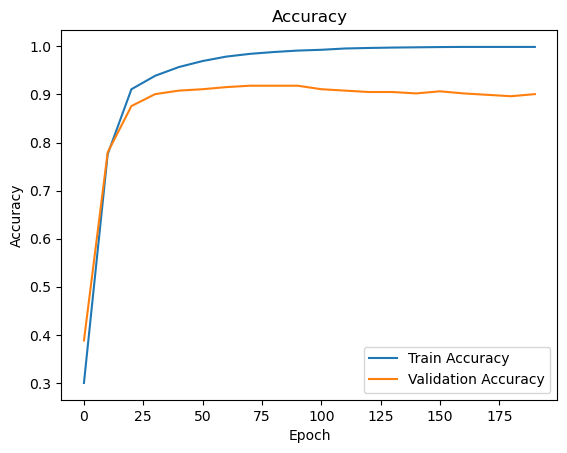

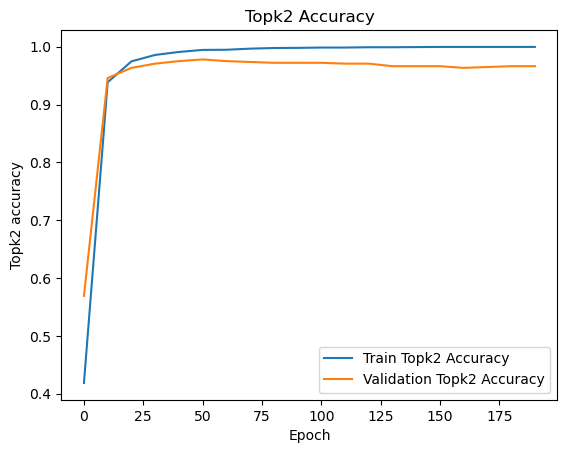

In [56]:
train_network('ngram_model_v2', ngram_model, ngram_train_loader, ngram_valid_loader, criterion, optimizer,
              num_epochs)

<h2>Model no.3 (POS n-grams)</h2>

In [57]:
def get_pos(text):
    doc = nlp(text)
    return " ".join([token.pos_ for token in doc])

In [58]:
X_train_pos = [get_pos(text) for text in X_train]
X_valid_pos = [get_pos(text) for text in X_valid]

In [59]:
vectorizer = TfidfVectorizer(ngram_range=(2,3))
vectorizer.fit(X_train_pos)
print(len(vectorizer.vocabulary_))

4020


In [60]:
pos_vectorizer = TfidfVectorizer(ngram_range=(2,3), max_features=500)

In [61]:
#Computing TF-IDF for POS n-grams
X_train_pos_tfidf = pos_vectorizer.fit_transform(X_train_pos)
X_valid_pos_tfidf = pos_vectorizer.transform(X_valid_pos)

In [62]:
#Balancing categories
sm = SMOTE(random_state=42)
X_train_pos_res, y_train_pos_res = sm.fit_resample(X_train_pos_tfidf.toarray(), y_train)

In [63]:
X_train_pos = torch.tensor(X_train_pos_res, dtype=torch.float32)
y_train_pos = torch.tensor(y_train_pos_res, dtype=torch.long)
X_valid_pos = torch.tensor(X_valid_pos_tfidf.toarray(), dtype=torch.float32)
y_valid_pos = torch.tensor(y_valid, dtype=torch.long)

In [64]:
pos_train = []
pos_valid = []
for val, target in zip(X_train_pos, y_train_pos):
    pos_train.append((val, target))
for val, target in zip(X_valid_pos, y_valid_pos):
    pos_valid.append((val, target))

pos_train_loader = torch.utils.data.DataLoader(pos_train, batch_size=128, shuffle=True)
pos_valid_loader = torch.utils.data.DataLoader(pos_valid, batch_size=128, shuffle=True)

In [65]:
class PosModel(nn.Module):
    def __init__(self, input_dim, h1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(h1, EMBED_DIM)
        )
        self.classifier = nn.Linear(EMBED_DIM, N_CLASSES)

    def forward(self, x, return_embedding=False):
        emb = self.encoder(x)
        if return_embedding:
            return emb
        return self.classifier(emb)

In [66]:
pos_input_dim = X_train_pos.shape[1]
pos_h1 = 128
pos_model = PosModel(pos_input_dim, pos_h1)
num_epochs = 150
lr = 0.0001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(pos_model.parameters(), lr=lr, weight_decay=1e-3)

Epoch 1 | Loss: 1.6109 | Train Acc: 0.200 | Valid Acc: 0.105
Epoch 11 | Loss: 1.3902 | Train Acc: 0.718 | Valid Acc: 0.720
Epoch 21 | Loss: 0.8762 | Train Acc: 0.790 | Valid Acc: 0.801
Epoch 31 | Loss: 0.5914 | Train Acc: 0.857 | Valid Acc: 0.867
Epoch 41 | Loss: 0.4332 | Train Acc: 0.897 | Valid Acc: 0.896
Epoch 51 | Loss: 0.3451 | Train Acc: 0.920 | Valid Acc: 0.923
Epoch 61 | Loss: 0.2812 | Train Acc: 0.933 | Valid Acc: 0.936
Epoch 71 | Loss: 0.2421 | Train Acc: 0.947 | Valid Acc: 0.949
Epoch 81 | Loss: 0.2110 | Train Acc: 0.956 | Valid Acc: 0.956
Epoch 91 | Loss: 0.1856 | Train Acc: 0.961 | Valid Acc: 0.958
Epoch 101 | Loss: 0.1632 | Train Acc: 0.967 | Valid Acc: 0.964
Epoch 111 | Loss: 0.1431 | Train Acc: 0.970 | Valid Acc: 0.962
Epoch 121 | Loss: 0.1350 | Train Acc: 0.975 | Valid Acc: 0.962
Epoch 131 | Loss: 0.1249 | Train Acc: 0.978 | Valid Acc: 0.961
Epoch 141 | Loss: 0.1084 | Train Acc: 0.980 | Valid Acc: 0.965


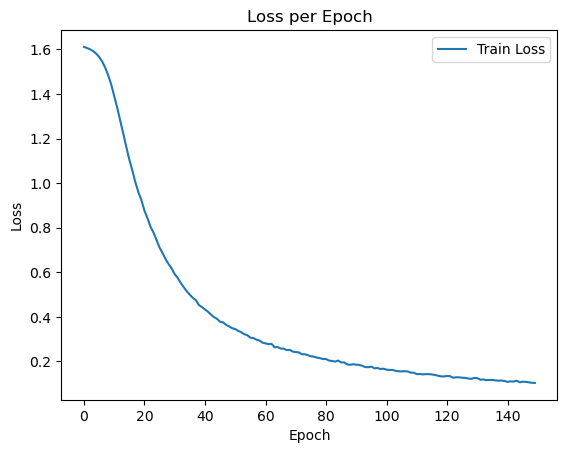

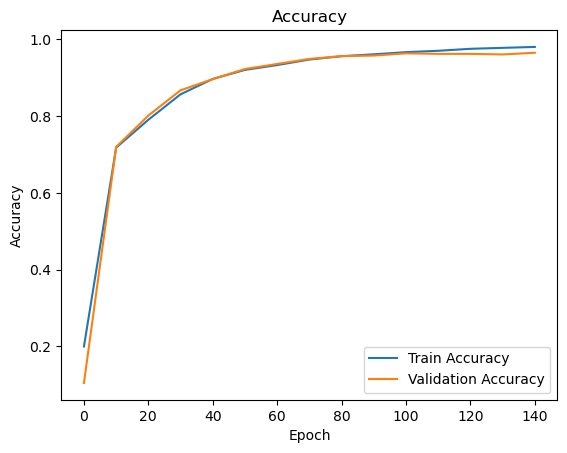

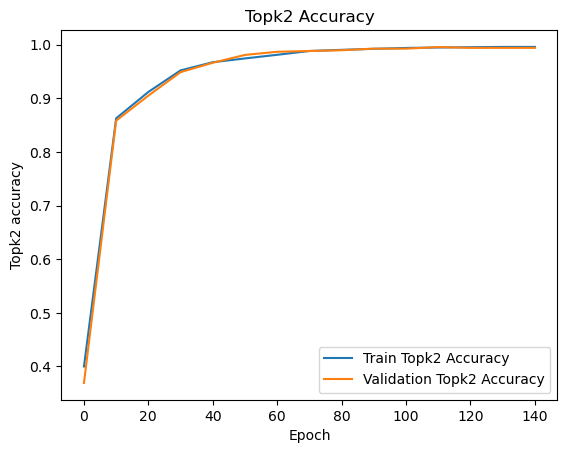

In [67]:
train_network('pos_model', pos_model, pos_train_loader, pos_valid_loader, criterion, optimizer,
              num_epochs)

<h2>Model no.4 (Fusion model)</h2>

In [68]:
fusion_train = [([stat, ngram, pos], label) for stat,ngram,pos,label in 
                zip (X_train_stat, X_train_ngram, X_train_pos, y_train_stat)]
fusion_valid = [([stat, ngram, pos], label) for stat,ngram,pos,label in 
                zip (X_valid_stat, X_valid_ngram, X_valid_pos, y_valid_stat)]

fusion_train_loader = torch.utils.data.DataLoader(fusion_train, batch_size=128, shuffle=True)
fusion_valid_loader = torch.utils.data.DataLoader(fusion_valid, batch_size=128, shuffle=True)

In [69]:
class FusionModel(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, n_classes=N_CLASSES):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(3*embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )
        for model in [stat_model, ngram_model, pos_model]:
            for param in model.parameters():
                param.requires_grad = False
                
    def forward(self, x):
        x_stat = x[0]
        x_ngram = x[1]
        x_pos = x[2]

        with torch.no_grad(): 
            e1 = stat_model(x_stat, return_embedding=True)
            e2 = ngram_model(x_ngram, return_embedding=True)
            e3 = pos_model(x_pos, return_embedding=True)
        
        x = torch.cat([e1, e2, e3], dim=1)
        return self.fc(x)

In [70]:
fusion_model = FusionModel()
num_epochs = 150
lr = 0.0001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(fusion_model.parameters(), lr=lr, weight_decay=1e-3)

Epoch 1 | Loss: 1.4794 | Train Acc: 0.983 | Valid Acc: 0.933
Epoch 11 | Loss: 0.1758 | Train Acc: 0.999 | Valid Acc: 0.974
Epoch 21 | Loss: 0.0533 | Train Acc: 0.998 | Valid Acc: 0.974
Epoch 31 | Loss: 0.0288 | Train Acc: 1.000 | Valid Acc: 0.980
Epoch 41 | Loss: 0.0195 | Train Acc: 1.000 | Valid Acc: 0.971
Epoch 51 | Loss: 0.0163 | Train Acc: 1.000 | Valid Acc: 0.980
Epoch 61 | Loss: 0.0117 | Train Acc: 1.000 | Valid Acc: 0.977
Epoch 71 | Loss: 0.0101 | Train Acc: 1.000 | Valid Acc: 0.975
Epoch 81 | Loss: 0.0089 | Train Acc: 1.000 | Valid Acc: 0.975
Epoch 91 | Loss: 0.0074 | Train Acc: 1.000 | Valid Acc: 0.978
Epoch 101 | Loss: 0.0081 | Train Acc: 1.000 | Valid Acc: 0.977
Epoch 111 | Loss: 0.0066 | Train Acc: 1.000 | Valid Acc: 0.975
Epoch 121 | Loss: 0.0069 | Train Acc: 1.000 | Valid Acc: 0.975
Epoch 131 | Loss: 0.0059 | Train Acc: 1.000 | Valid Acc: 0.981
Epoch 141 | Loss: 0.0060 | Train Acc: 1.000 | Valid Acc: 0.978


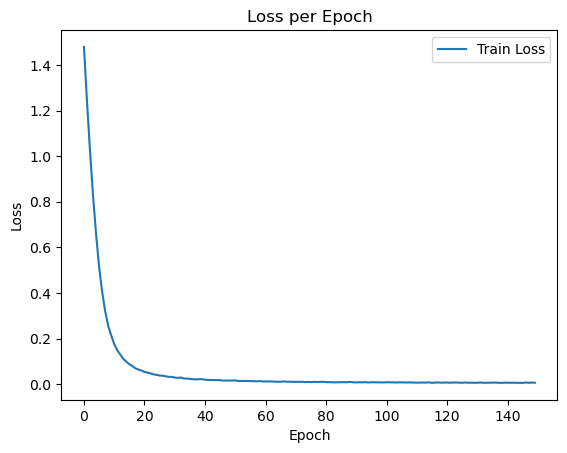

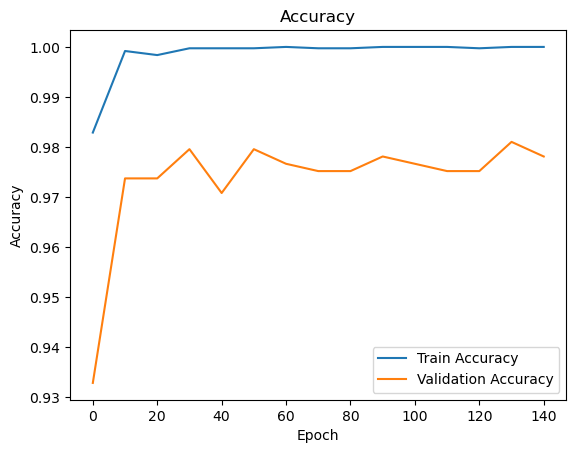

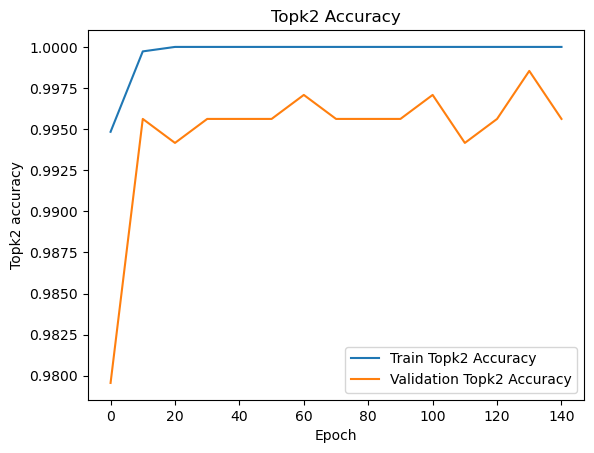

In [71]:
train_network('fusion_model', fusion_model, fusion_train_loader, fusion_valid_loader,
              criterion, optimizer, num_epochs)

<h2>Model no.5 (HerBERT)</h2>

In [72]:
model_name = 'allegro/herbert-base-cased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        max_length=128,
        padding="max_length",
        truncation=True
    )

herbert_train_dataset = Dataset.from_dict({"text": X_train, "label": y_train})
herbert_valid_dataset = Dataset.from_dict({"text": X_valid, "label": y_valid})

herbert_train_dataset = herbert_train_dataset.map(tokenize, batched=True)
herbert_valid_dataset = herbert_valid_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/2738 [00:00<?, ? examples/s]

Map:   0%|          | 0/685 [00:00<?, ? examples/s]

In [76]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

herbert_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=N_CLASSES
)
herbert_model.to(device)
lr = 2e-5
optimizer = torch.optim.Adam(herbert_model.parameters(), lr=lr)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at allegro/herbert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [77]:
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    
    predictions = np.argmax(logits, axis=1)
    
    return accuracy_metric.compute(predictions=predictions, references=labels)

In [78]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_dir="./logs",
    logging_strategy="epoch",
    eval_strategy='epoch',
    save_strategy='epoch',
    include_inputs_for_metrics=True
)

trainer = Trainer(
    model=herbert_model,
    args=training_args,
    train_dataset=herbert_train_dataset,
    eval_dataset=herbert_valid_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Using `include_inputs_for_metrics` is deprecated and will be removed in version 5 of 🤗 Transformers. Please use `include_for_metrics` list argument instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.038200,0.499694,0.805839
2,0.303300,0.306238,0.900730
3,0.094300,0.253369,0.940146
4,0.026400,0.258637,0.944526
5,0.002800,0.266335,0.941606


/home/max/miniconda3/envs/nlp/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/home/max/miniconda3/envs/nlp/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/home/max/miniconda3/envs/nlp/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/home/max/miniconda3/envs/nlp/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=860, training_loss=0.29300495285627454, metrics={'train_runtime': 7029.4987, 'train_samples_per_second': 1.948, 'train_steps_per_second': 0.122, 'total_flos': 900521842583040.0, 'train_loss': 0.29300495285627454, 'epoch': 5.0})

In [79]:
def plot_trainer_history(trainer):
    history = trainer.state.log_history
    
    train_acc = [x["train_accuracy"] for x in history if "train_accuracy" in x]
    val_acc = [x["eval_accuracy"] for x in history if "eval_accuracy" in x]
    train_loss = [x["loss"] for x in history if "loss" in x and "eval_loss" not in x]

    plt.figure()
    plt.title("Accuracy")
    plt.plot(range(1, len(val_acc) + 1), val_acc, label = "Validation Accuracy")
    #plt.plot(range(1, len(train_acc) + 1), train_acc, label = "Train Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.savefig(PLOTS_DIR / f'herbert_acc.png', dpi=300)
    plt.show()

    plt.figure()
    plt.title("Loss per Epoch")
    plt.plot(range(1, len(train_loss) + 1), train_loss)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.savefig(PLOTS_DIR / f'herbert_loss.png', dpi=300)
    plt.show()

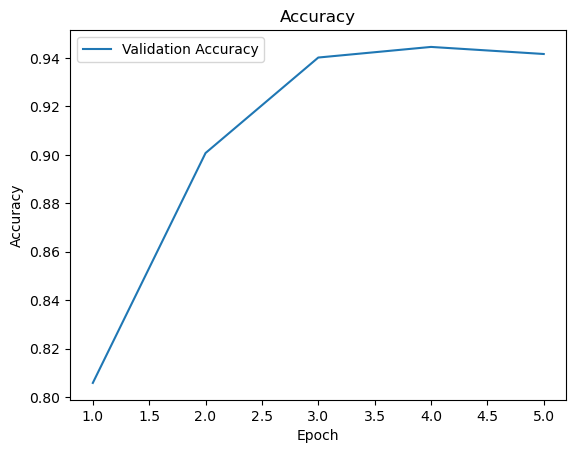

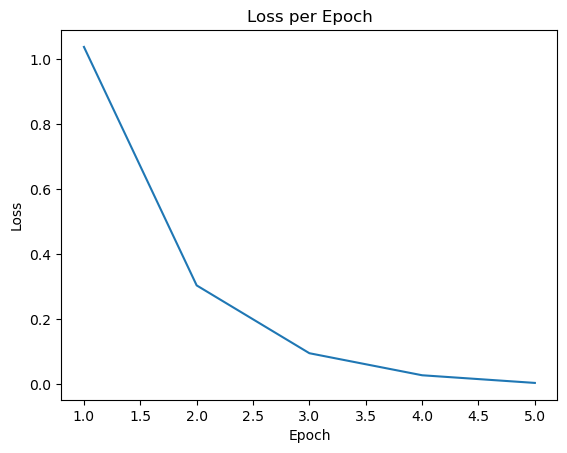

In [80]:
plot_trainer_history(trainer)

<h2>Model no.6 (Stack model)</h2>

In [81]:
X_train_stat = np.hstack([X_train_stat_num, X_train_stat_tfidf.toarray()])
X_valid_stat = np.hstack([X_valid_stat_num, X_valid_stat_tfidf.toarray()])
X_train_stat = torch.tensor(X_train_stat, dtype=torch.float32)
y_train_stat = torch.tensor(y_train, dtype=torch.long)
X_valid_stat = torch.tensor(X_valid_stat, dtype=torch.float32)
y_valid_stat = torch.tensor(y_valid, dtype=torch.long)

X_train_ngram = torch.tensor(X_train_ngram_tfidf.toarray(), dtype=torch.float32)
y_train_ngram = torch.tensor(y_train, dtype=torch.long)
X_valid_ngram = torch.tensor(X_valid_ngram_tfidf.toarray(), dtype=torch.float32)
y_valid_ngram = torch.tensor(y_valid, dtype=torch.long)

X_train_pos = torch.tensor(X_train_pos_tfidf.toarray(), dtype=torch.float32)
y_train_pos = torch.tensor(y_train, dtype=torch.long)
X_valid_pos = torch.tensor(X_valid_pos_tfidf.toarray(), dtype=torch.float32)
y_valid_pos = torch.tensor(y_valid, dtype=torch.long)

fusion_train = [([stat, ngram, pos], label) for stat,ngram,pos,label in 
                zip (X_train_stat, X_train_ngram, X_train_pos, y_train_stat)]
fusion_valid = [([stat, ngram, pos], label) for stat,ngram,pos,label in 
                zip (X_valid_stat, X_valid_ngram, X_valid_pos, y_valid_stat)]

In [82]:
print(X_train_stat.shape)
print(X_train_ngram.shape)
print(X_train_pos.shape)

torch.Size([2738, 35])
torch.Size([2738, 500])
torch.Size([2738, 500])


In [83]:
herbert_train_preds = trainer.predict(herbert_train_dataset)
herbert_valid_preds = trainer.predict(herbert_valid_dataset)

herbert_train_logits = torch.tensor(herbert_train_preds.predictions)
herbert_valid_logits = torch.tensor(herbert_valid_preds.predictions)

/home/max/miniconda3/envs/nlp/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


/home/max/miniconda3/envs/nlp/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [84]:
class StackDataset(torch.utils.data.Dataset):
    def __init__(self, fusion_data, herbert_logits):
        self.fusion_data = fusion_data
        self.herbert_logits = herbert_logits
    
    def __len__(self):
        return len(self.fusion_data)

    def __getitem__(self, idx):
        [stat, ngram, pos], label = self.fusion_data[idx]
        herbert_logit = self.herbert_logits[idx]
        return ([stat, ngram, pos], herbert_logit), label
        
stack_train_dataset = StackDataset(fusion_train, herbert_train_logits)
stack_valid_dataset = StackDataset(fusion_valid, herbert_valid_logits)

stack_train_loader = torch.utils.data.DataLoader(stack_train_dataset, batch_size=128, shuffle=True)
stack_valid_loader = torch.utils.data.DataLoader(stack_valid_dataset, batch_size=128, shuffle=True)

In [85]:
class StackModel(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.fusion_model = fusion_model
        self.fc = nn.Linear(2*n_classes, n_classes)
        for param in fusion_model.parameters():
            param.requires_grad = False
        
    def forward(self, x):
        with torch.no_grad():
            fusion_logits = self.fusion_model(x[0])
        
        fusion_probs = torch.softmax(fusion_logits, dim=-1) #softmax aby zwracało prawd.
        herbert_probs = torch.softmax(x[1], dim=-1) #wcześniej nie trzeba było używać bo było CrossEntropy
        
        x = torch.cat([fusion_probs, herbert_probs], dim=-1)
        return self.fc(x)

In [86]:
stack_model = StackModel()
num_epochs = 150
lr = 0.0001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(stack_model.parameters(), lr=lr, weight_decay=1e-3)

Epoch 1 | Loss: 1.6067 | Train Acc: 0.309 | Valid Acc: 0.267
Epoch 11 | Loss: 1.5326 | Train Acc: 0.309 | Valid Acc: 0.272
Epoch 21 | Loss: 1.4627 | Train Acc: 0.309 | Valid Acc: 0.270
Epoch 31 | Loss: 1.3937 | Train Acc: 0.309 | Valid Acc: 0.276
Epoch 41 | Loss: 1.3286 | Train Acc: 0.734 | Valid Acc: 0.670
Epoch 51 | Loss: 1.2646 | Train Acc: 0.999 | Valid Acc: 0.965
Epoch 61 | Loss: 1.2040 | Train Acc: 1.000 | Valid Acc: 0.965
Epoch 71 | Loss: 1.1462 | Train Acc: 1.000 | Valid Acc: 0.975
Epoch 81 | Loss: 1.0885 | Train Acc: 1.000 | Valid Acc: 0.974
Epoch 91 | Loss: 1.0342 | Train Acc: 1.000 | Valid Acc: 0.971
Epoch 101 | Loss: 0.9826 | Train Acc: 1.000 | Valid Acc: 0.972
Epoch 111 | Loss: 0.9339 | Train Acc: 1.000 | Valid Acc: 0.974
Epoch 121 | Loss: 0.8862 | Train Acc: 1.000 | Valid Acc: 0.978
Epoch 131 | Loss: 0.8399 | Train Acc: 1.000 | Valid Acc: 0.975
Epoch 141 | Loss: 0.7973 | Train Acc: 1.000 | Valid Acc: 0.977


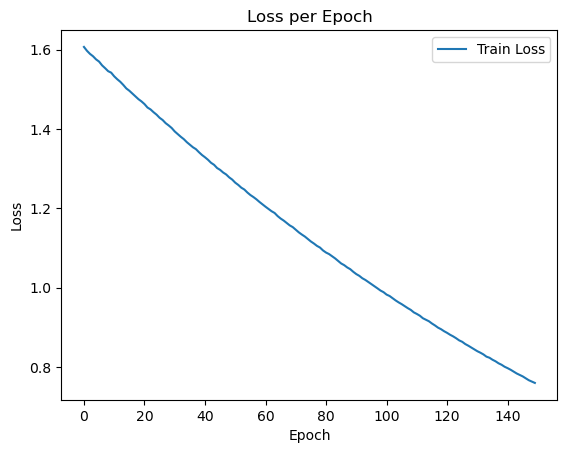

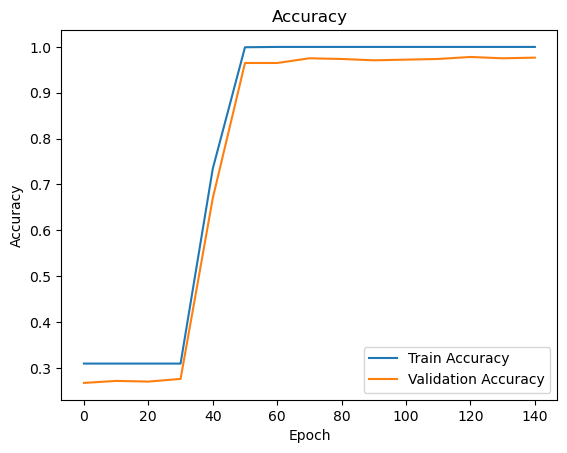

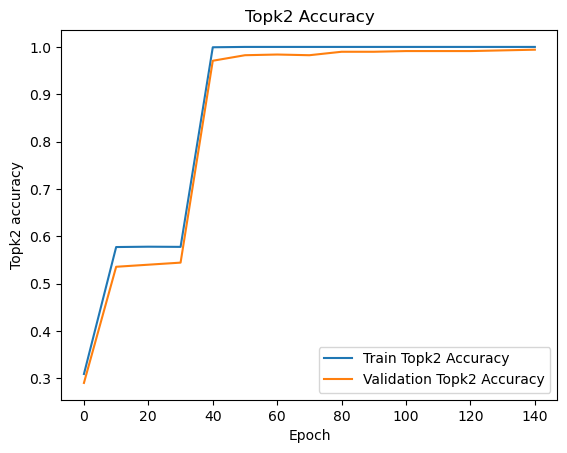

In [87]:
train_network('stack_model', stack_model, stack_train_loader, stack_valid_loader,
              criterion, optimizer, num_epochs)

<h2>Performence on test dataset</h2>

In [88]:
#Extracting statistics
X_test_stat_num = [get_statistics(text) for text in X_test] 
#Normalization
X_test_stat_num = scaler.transform(X_test_stat_num)
#Computing TF-IDF for tokens
X_test_stat_tfidf = stat_vectorizer.transform(X_test)
#Merging data
X_test_stat = np.hstack([X_test_stat_num, X_test_stat_tfidf.toarray()])

X_test_stat = torch.tensor(X_test_stat, dtype=torch.float32)
y_test_stat = torch.tensor(y_test, dtype=torch.long)

In [89]:
vectorizer = TfidfVectorizer(ngram_range=(2,3), max_features=500)
X_test_mask = [mask_entity(text) for text in X_test]
#Computing TF-IDF for n-grams
X_test_ngram_tfidf = ngram_vectorizer.transform(X_test_mask)
X_test_ngram = torch.tensor(X_test_ngram_tfidf.toarray(), dtype=torch.float32)
y_test_ngram = torch.tensor(y_test, dtype=torch.long)

In [90]:
X_test_pos = [get_pos(text) for text in X_test]
#Computing TF-IDF for POS n-grams
X_test_pos_tfidf = pos_vectorizer.transform(X_test_pos)
X_test_pos = torch.tensor(X_test_pos_tfidf.toarray(), dtype=torch.float32)
y_test_pos = torch.tensor(y_test, dtype=torch.long)

In [91]:
fusion_test = [([stat, ngram, pos], label) for stat,ngram,pos,label in 
                zip (X_test_stat, X_test_ngram, X_test_pos, y_test_stat)]

In [92]:
herbert_test_dataset = Dataset.from_dict({"text": X_test, "label": y_test})
herbert_test_dataset = herbert_test_dataset.map(tokenize, batched=True)

herbert_test_preds = trainer.predict(herbert_test_dataset)
herbert_test_logits = torch.tensor(herbert_test_preds.predictions)

Map:   0%|          | 0/856 [00:00<?, ? examples/s]

/home/max/miniconda3/envs/nlp/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [93]:
stack_test_dataset = StackDataset(fusion_test, herbert_test_logits)
stack_test_loader = torch.utils.data.DataLoader(stack_test_dataset, batch_size=128)

In [94]:
stack_model.eval()
y_pred, y = [], []
with torch.no_grad():
    for embeds, labels in stack_test_loader:
        logits = stack_model(embeds)
        preds = torch.argmax(logits, dim=1)
        y_pred.extend(preds.tolist())
        y.extend(labels.tolist())
from sklearn.metrics import classification_report
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       236
           1       0.98      1.00      0.99       238
           2       0.99      0.95      0.97       126
           3       0.96      0.95      0.96       169
           4       0.99      0.97      0.98        87

    accuracy                           0.98       856
   macro avg       0.98      0.97      0.97       856
weighted avg       0.98      0.98      0.98       856

